# 06 — Per-sensor track crossings: the tracker-readout route

Notebook 05 extracted the full shower cascade. **This notebook reduces it to the product this
simulation was asked to deliver**: one record per **charged-track crossing of a silicon
sensor** — where it hit, which way it was going, how fast, and what it was — for every one of
the thousands of crossings in the shower. That per-crossing table is what a detailed
sensor-level simulation (such as our collaborators' silicon charge-transport code, PIXELAV)
consumes; here we produce it and defend every field in it.

**How the crossings are obtained — the silicon is read out as a tracker.** A calorimeter
records energy deposits; it does not record a track's *momentum*. So the simulation is run
once more with the ECal silicon configured as a Geant4 **tracker** (one steering line, §2). A
tracker sensitive detector produces one `SimTrackerHit` per sensor crossing carrying exactly
what we need — **position, momentum and path length** — with no reconstruction on our part.

> **There are two complementary ways to build these crossings, and both matter (see §2b).**
> This notebook — **06** — uses the **tracker** readout, which gives the real per-crossing
> **momentum** directly. Its companion [**07**](07_sensor_crossings_calo.ipynb) builds the
> same crossings from the **calorimeter** step-energy truth (`CaloHitContribution`s,
> time-ordered): that route gives an entry-anchored position and the full step-level deposit,
> but only the *production* momentum. 06 is the route when the βγ / dE/dx regime matters (the
> momentum is real); 07 applies when only a calorimeter readout is available, or when
> step-level detail is needed — and because the two are independent readouts of the *same*
> shower, their agreement (§8) is an independent cross-check.

**Units.** Positions and impact points in mm (sensor-local frame); momenta and energies in GeV.


## 1. What a sensor-level simulation needs — and why energy deposits are *not* it

A detailed silicon simulation (a charge-transport code such as PIXELAV) does **not** consume
Geant4's energy deposits: given a charged track's geometry and kinematics it **generates the
ionization itself**, δ-rays included, then drifts, diffuses and traps the electron–hole pairs
through the sensor's electric and magnetic fields to produce the induced pixel signal. So the
interface is **track kinematics**, per crossing, in the sensor's **local** frame (`u` across
the pitch, `v` along cylinder-z, `w` the sensor-normal / depth axis):

- the **local impact point** `(u, v)` on the sensor;
- the **direction slopes** `cot α = p_u/p_w`, `cot β = p_v/p_w` (the standard pixel-sensor
  convention for track inclination);
- the **momentum magnitude** `|p|` — it sets the βγ and therefore the dE/dx regime (a
  relativistic MIP ionizes very differently from a soft, sub-MeV electron);
- the **particle type**.

Whole-track endpoints from notebook 05 are not enough: an `MCParticle`'s vertex/endpoint
bracket its *entire* trajectory, possibly several sensors apart, whereas sensor-level
simulation works **one sensor crossing at a time**. The per-crossing truth is what we surface
here.


## 2. The method — read the silicon out as a Geant4 tracker

The calorimeter readout writes `CaloHitContribution`s with a step's position and energy but **no
momentum** (the EDM4hep schema has no momentum field). To get the real per-crossing momentum we
map the ECal silicon to Geant4's tracker sensitive action — one line in
[`sim/run_sim_trackermom.py`](../sim/run_sim_trackermom.py):

```python
SIM.action.mapActions['ECalBarrel'] = 'Geant4TrackerWeightedAction'
```

A tracker SD combines the steps of one sensor crossing into a single **`SimTrackerHit`** carrying
`position`, **`momentum`**, `pathLength`, `eDep`, `time` and a link to the producing `MCParticle`.
That *is* one crossing record — directly, with no time-ordering reconstruction. Same gun,
physics list and random seed (424242) as the calorimeter cascade, so the shower is identical; only
the Si readout differs.

Run it on EAF (Key4hep sourced; `ddsim` needs `lib_hack` on `LD_LIBRARY_PATH`, handbook §6.3):

```bash
export LD_LIBRARY_PATH=$HOME/lib_hack:$LD_LIBRARY_PATH
ddsim --compactFile SiD_TestBeam.xml --steeringFile ../sim/run_sim_trackermom.py --numberOfEvents 1
python ../analysis/extract_trackermom.py     # -> models/trackermom_*.npz (per-crossing momentum)
python ../analysis/sensor_crossings.py       # -> models/sensor_crossings_* records (auto-selects variant C)
```

`sensor_crossings.build_segments_C` turns each `SimTrackerHit` into one crossing record. The cell
below loads them. Each record's complete field schema is documented in §7 (the hand-off).

In [1]:
import os, sys, json
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
sys.path.insert(0, os.path.abspath('../analysis'))
import sensor_crossings as sc

def _find(name):
    for base in ['../models', 'models', os.path.join(os.environ.get('CALOMAPS_HOME', '..'), 'models')]:
        p = os.path.join(base, name)
        if os.path.exists(p): return p
    return os.path.join('../models', name)

dT = np.load(_find('trackermom_gamma50_1evt.npz'), allow_pickle=True)
segs, stats = sc.build_segments_C(dT)                  # one record per SimTrackerHit crossing
print(f'{len(segs)} per-sensor crossings from {len(dT["thx"])} tracker hits; {stats}')

# unpack the payload into arrays
p_GeV  = np.array([s['p_GeV']    for s in segs])
eu     = np.array([s['entry_u']  for s in segs])       # mm, local across-pitch
ev     = np.array([s['entry_v']  for s in segs])       # mm, local cylinder-z
cota   = np.array([s['cot_alpha'] for s in segs])
cotb   = np.array([s['cot_beta']  for s in segs])
layer  = np.array([s['layer_id'] for s in segs])
pdg    = np.array([s['pdg']      for s in segs])
depthw = np.array([s['depth_w_mm'] for s in segs])
trk    = np.array([s['track_id'] for s in segs])
print(f'example record: {segs[0]}')

3217 per-sensor crossings from 3241 tracker hits; {'neutral_hits_skipped': 24, 'n_tracker_hits': 3241}
example record: {'track_id': 1, 'layer_id': 8, 'pdg': 11, 'p_GeV': 46.8992919921875, 'entry_u': 0.00016671580662463162, 'entry_v': -4.556476577411556e-05, 'cot_alpha': 0.00011181959257310972, 'cot_beta': -3.7477857425849126e-05, 'flipped': 1, 'sensor_normal_phi': 1.5707963267948966, 'depth_w_mm': 1297.0099999999998, 'energy_dep_GeV': 0.0001066317199729383, 'n_steps': 1, 'time_ns': 4.326893329620361, 'variant': 'C', 'flags': 'tracker_hit'}


## 2b. The two silicon readouts — what each stores, and what each is for

The same silicon can be read out two ways, and CALOMAPS uses **both**, for different jobs.
Side by side:

| | Calorimeter readout | Tracker readout (this notebook) |
|---|---|---|
| EDM4hep object | `SimCalorimeterHit` + `CaloHitContribution` | `SimTrackerHit` |
| Granularity | energy summed per 100 µm pixel; one contribution per Geant4 step | one hit per **sensor crossing** |
| Stores | deposited **energy**, position, time, MCParticle link | **momentum**, position (energy-weighted ≈ mid-plane), `pathLength`, `eDep`, time, MCParticle link |
| Carries momentum? | **no** (not in the schema) | **yes** |
| Steering | default (`type="calorimeter"`) | `mapActions['ECalBarrel']='Geant4TrackerWeightedAction'` |
| Used by | notebooks 01–05 and 07 | this notebook (06) |

The sensitive detector is a **passive observer** — it decides only *what is recorded*, not how
particles propagate. We verified this: the two runs (same seed) produce a **byte-identical**
MCParticle cascade (78,270 particles, identical momenta and vertices — §8). So the tracker
readout is not different physics; it is the same shower, recorded with the one field the
crossing records need — momentum — that the calorimeter schema does not carry.

**Primary vs secondary: the discriminator is the birth point, not the generator.** Every
silicon crossing in this event is a Geant4 *shower secondary* — the generator primary is the
50 GeV photon, which does not ionize — so "generator primary vs secondary" separates nothing.
What matters for a device simulation is **where the particle was born**:
- **born outside the sensor**, crossing it — an ionizing track (~88% here, median KE ~19 MeV,
  most traversing the full 320 µm). These are the tracks a single-track sensor simulation is
  built for.
- **born inside the sensor** — a delta ray knocked out by local ionization (~12%, median KE
  ~0.5 MeV, almost all with `pathLength` < 320 µm). A charge-transport code regenerates
  in-sensor delta rays itself, so these are not independent inputs.

**Division of labour:**
- **Tracker readout → per-crossing records** answers *per-crossing device physics*: cluster
  shape, charge sharing, single-hit position resolution — the device-level observables a
  detailed sensor simulation predicts.
- **Calorimeter readout → deposit-driven digitization** answers the *full-shower digital
  readout*: which pixels fire across all 30 layers (MIPs-per-pixel, clusters, shower
  profiles, the resolution fits — notebooks 01–04). This is the detector's actual measurement
  and the field-standard way to get a high-granularity calorimeter's per-pixel response
  (Allpix²-style digitization).

They are complementary, not interchangeable: summing a per-crossing device response over a
whole shower is *not* an energy-conserving readout (in-sensor delta rays would be
double-counted against the full-event calorimeter readout), and the calorimeter readout
cannot give the sub-pixel device physics. Use each for what it is for.


## 3. The local frame and two geometry choices

The ECal is a 12-sided Si–W barrel with its axis along z; each flat face's outward normal points
radially. For a crossing we rotate into the local frame where **`w`** is the sensor normal (depth),
**`u`** is across the pitch and **`v`** is the cylinder-z axis — a standard pixel-sensor local frame. Two
choices in that mapping are easy to get subtly wrong; both are fixed by the data below:

- **Where is the face?** The dodecagon could present a face *centre* or a *vertex* at +y. The hit
  azimuth peaks sharply at **90°**, so the +y beam strikes a face *centre* (`FACE_PHI0 = 0`).
  Getting this wrong by 15° would throw the local entry point off by `r·sin15° ≈ 300 mm`.
- **What labels a layer — radius or depth?** The sensors are **flat**, so a layer sits at constant
  **depth** `w` (perpendicular face distance), *not* constant radius `r=√(x²+y²)`. Assigning by
  radius mislabels wide-shower crossings into the wrong layer; assigning by **depth** keeps every
  crossing within a sub-mm of its geometric layer centre. The right panel shows both.

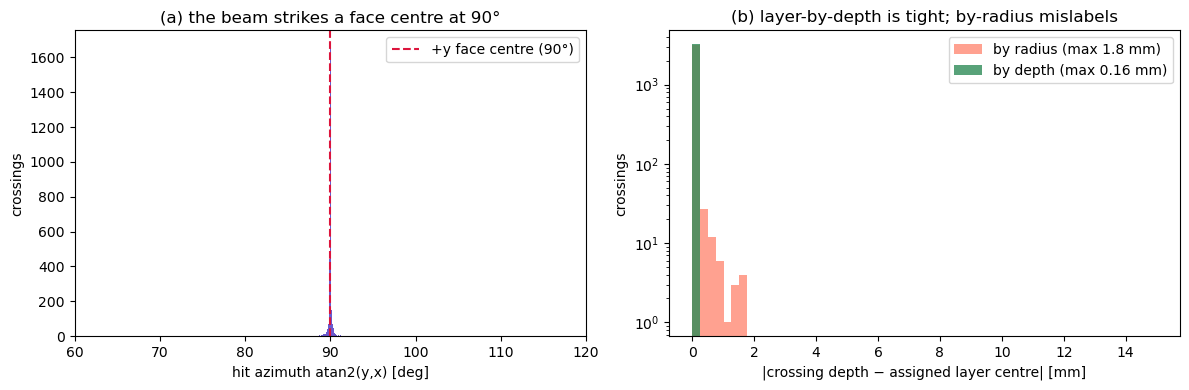

In [2]:
thx, thy = dT['thx'], dT['thy']
phin = sc.face_phi(thx, thy)
centers = sc.si_layer_centers()
wdep = thx*np.cos(phin) + thy*np.sin(phin)             # depth (face-normal projection)
r    = np.sqrt(thx**2 + thy**2)
lay_depth  = np.argmin(np.abs(wdep[:, None] - centers[None, :]), axis=1)
lay_radius = np.argmin(np.abs(r[:, None]    - centers[None, :]), axis=1)
resid_depth  = np.abs(wdep - centers[lay_depth])
resid_radius = np.abs(r    - centers[lay_radius])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.degrees(np.arctan2(thy, thx)), bins=120, color='slateblue')
ax[0].axvline(90, color='crimson', ls='--', label='+y face centre (90°)')
ax[0].set_xlabel('hit azimuth atan2(y,x) [deg]'); ax[0].set_ylabel('crossings'); ax[0].set_xlim(60, 120)
ax[0].set_title('(a) the beam strikes a face centre at 90°'); ax[0].legend()
ax[1].hist(resid_radius, bins=np.linspace(0, 15, 60), alpha=0.6, color='tomato', label=f'by radius (max {resid_radius.max():.1f} mm)')
ax[1].hist(resid_depth,  bins=np.linspace(0, 15, 60), alpha=0.8, color='seagreen', label=f'by depth (max {resid_depth.max():.2f} mm)')
ax[1].set_xlabel('|crossing depth − assigned layer centre| [mm]'); ax[1].set_ylabel('crossings')
ax[1].set_title('(b) layer-by-depth is tight; by-radius mislabels'); ax[1].legend(); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()

## 4. The payload — the per-sensor crossing records

One record per crossing, everything a sensor-level simulation needs. The four panels:

- **(a) Local impact points** — where on the sensor face each crossing sits, pooled over all
  30 layers, measured from the detector axis (`(0,0)` = the +y beam axis). The ±tens-of-mm
  spread is the shower's transverse footprint — of order the stack's Molière radius (~1 cm,
  notebook 01 §6b) — not the 100 µm pitch. The *sub-pixel* impact within a sensor is a
  separate, finer coordinate; the records carry each crossing's **real** impact, so a
  downstream consumer can use the true sub-pixel position rather than sampling one.
- **(b) Direction vs momentum** — `cot α` split into momentum bands: hard tracks pile up at
  `cot α ≈ 0` (perpendicular), soft tracks fan out — the expected EM-shower behaviour.
- **(c) Crossing-momentum spectrum** — the **real** per-crossing momentum (validated in §5).
  It rises to a peak around a few MeV: the soft sub-MeV particles born in the dense tungsten
  are absorbed before reaching silicon, so only those energetic enough to reach (and cross
  more of) the sensors register.
- **(d) Crossings per layer** — the longitudinal shower profile in track crossings: rising
  from the front, a maximum near shower-max, then the dying tail — the same depth dependence
  as the energy profile in notebooks 02/05.


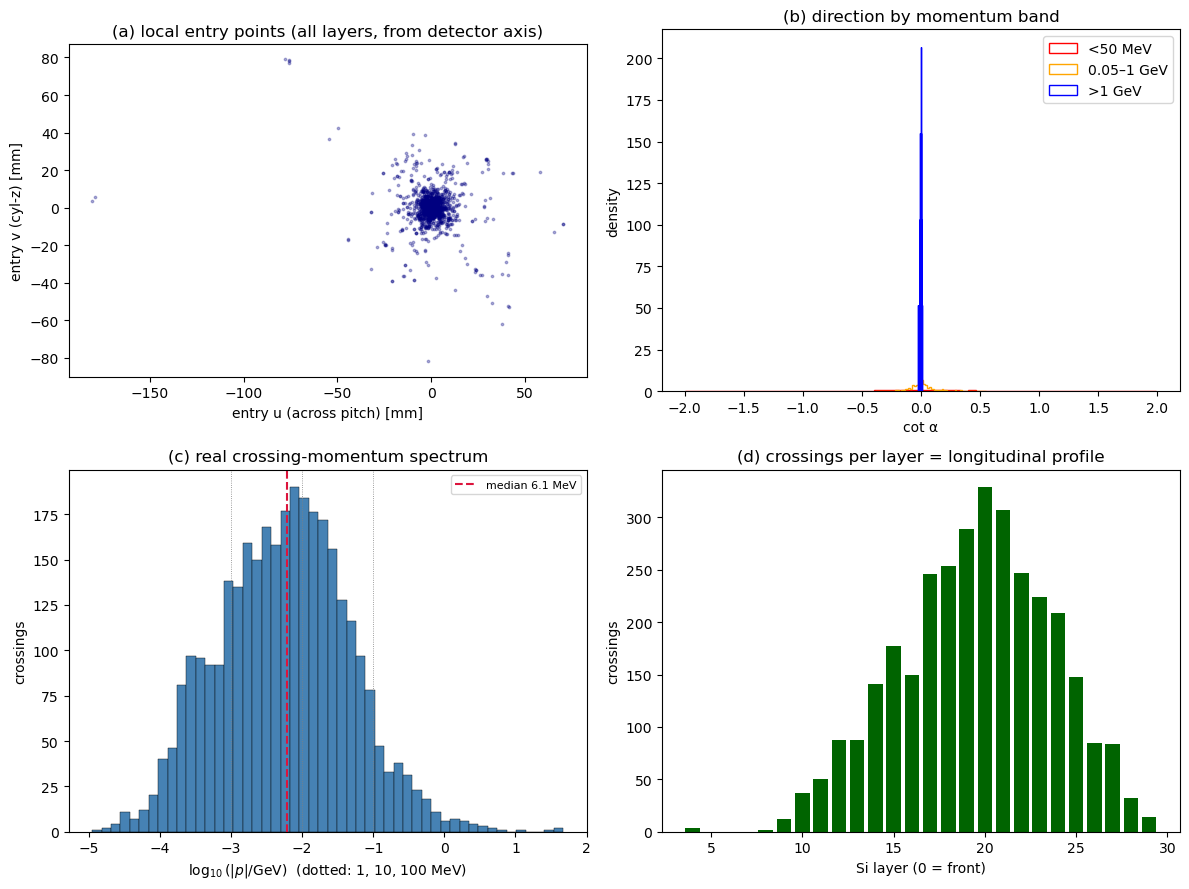

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
# (a) local entry points
ax[0,0].scatter(eu, ev, s=3, alpha=0.3, color='navy')
ax[0,0].set_xlabel('entry u (across pitch) [mm]'); ax[0,0].set_ylabel('entry v (cyl-z) [mm]')
ax[0,0].set_title('(a) local entry points (all layers, from detector axis)'); ax[0,0].set_aspect('equal')
# (b) cot alpha in momentum bands
for lo, hi, c, lab in [(0,0.05,'red','<50 MeV'),(0.05,1,'orange','0.05–1 GeV'),(1,1e9,'blue','>1 GeV')]:
    m = (p_GeV>=lo)&(p_GeV<hi)&np.isfinite(cota)&(np.abs(cota)<2)
    if m.sum(): ax[0,1].hist(cota[m], bins=60, histtype='step', color=c, label=lab, density=True)
ax[0,1].set_xlabel('cot α'); ax[0,1].set_ylabel('density'); ax[0,1].set_title('(b) direction by momentum band'); ax[0,1].legend()
# (c) momentum spectrum
pp = p_GeV[p_GeV>0]
ax[1,0].hist(np.log10(pp), bins=50, color='steelblue', edgecolor='k', lw=0.3)
ax[1,0].axvline(np.log10(np.median(pp)), color='crimson', ls='--', label=f'median {np.median(pp)*1e3:.1f} MeV')
for mev in [1, 10, 100]: ax[1,0].axvline(np.log10(mev/1e3), color='gray', ls=':', lw=0.6)
ax[1,0].set_xlabel(r'$\log_{10}(|p|/\mathrm{GeV})$  (dotted: 1, 10, 100 MeV)'); ax[1,0].set_ylabel('crossings'); ax[1,0].set_title('(c) real crossing-momentum spectrum'); ax[1,0].legend(fontsize=8)
# (d) crossings per layer
L = np.arange(layer.min(), layer.max()+1)
ax[1,1].bar(L, [np.sum(layer==l) for l in L], color='darkgreen')
ax[1,1].set_xlabel('Si layer (0 = front)'); ax[1,1].set_ylabel('crossings'); ax[1,1].set_title('(d) crossings per layer = longitudinal profile')
plt.tight_layout(); plt.show()

## 5. The momentum, validated

Because the tracker hit carries the **true Geant4 momentum at the crossing**, the records do
not reuse a particle's production momentum for its deep crossings (the calorimeter route's
main limitation — see notebook [07](07_sensor_crossings_calo.ipynb)). Four checks:
- **(a)** the per-crossing momentum spectrum (real) peaks at a few MeV — the soft EM shower;
- **(b)** each crossing's momentum vs its producing particle's *production* momentum sits **on
  or below the diagonal** — the empty region *above* it is the confirmation (a point there
  would mean energy gained after birth, which cannot happen);
- **(c)** the median momentum **falls with depth** as the shower softens;
- **(d)** the leading conversion electron, crossing-by-crossing, loses momentum **overall**
  from tens of GeV as it radiates through the stack (small non-monotone steps from re-linked
  secondaries are possible).


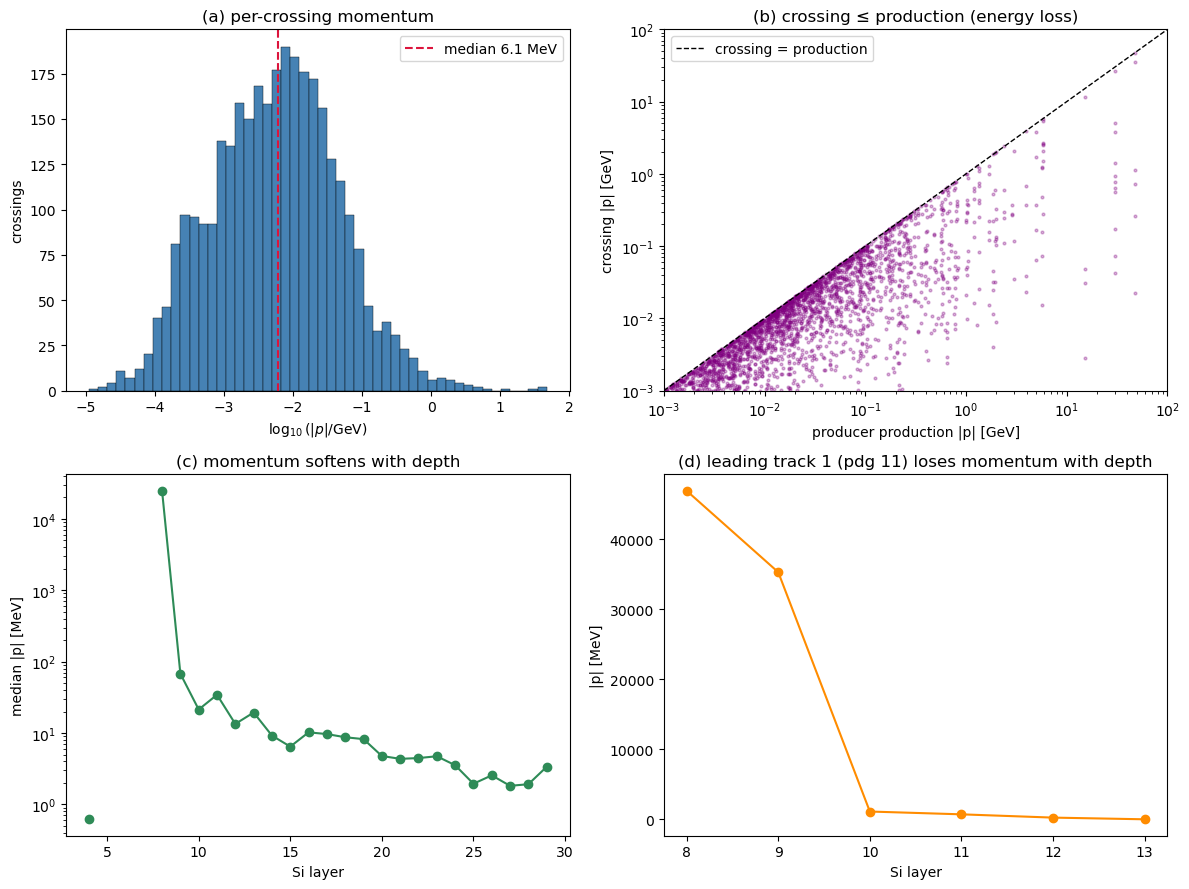

In [4]:
pprod = np.sqrt(dT['px'][trk]**2 + dT['py'][trk]**2 + dT['pz'][trk]**2)
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
m = p_GeV > 0
ax[0,0].hist(np.log10(p_GeV[m]), bins=50, color='steelblue', edgecolor='k', lw=0.3)
ax[0,0].axvline(np.log10(np.median(p_GeV[m])), color='crimson', ls='--', label=f'median {np.median(p_GeV[m])*1e3:.1f} MeV')
ax[0,0].set_xlabel(r'$\log_{10}(|p|/\mathrm{GeV})$'); ax[0,0].set_ylabel('crossings'); ax[0,0].set_title('(a) per-crossing momentum'); ax[0,0].legend()
good = (p_GeV>0)&(pprod>0)
ax[0,1].scatter(pprod[good], p_GeV[good], s=4, alpha=0.3, color='purple')
lim=[1e-3,1e2]; ax[0,1].plot(lim,lim,'k--',lw=1,label='crossing = production')
ax[0,1].set_xscale('log'); ax[0,1].set_yscale('log'); ax[0,1].set_xlim(lim); ax[0,1].set_ylim(lim)
ax[0,1].set_xlabel('producer production |p| [GeV]'); ax[0,1].set_ylabel('crossing |p| [GeV]'); ax[0,1].set_title('(b) crossing ≤ production (energy loss)'); ax[0,1].legend()
Lp = np.arange(layer.min(), layer.max()+1)
medp = [np.median(p_GeV[layer==l]) if np.any(layer==l) else np.nan for l in Lp]
ax[1,0].plot(Lp, np.array(medp)*1e3, 'o-', color='seagreen'); ax[1,0].set_yscale('log')
ax[1,0].set_xlabel('Si layer'); ax[1,0].set_ylabel('median |p| [MeV]'); ax[1,0].set_title('(c) momentum softens with depth')
cand=[(t,(trk==t).sum(),pprod[trk==t][0]) for t in np.unique(trk)]
pool=[c for c in cand if c[1]>=3] or cand; lead=max(pool, key=lambda c:c[2])[0]
sel=trk==lead; o=np.argsort(layer[sel])
ax[1,1].plot(layer[sel][o], p_GeV[sel][o]*1e3, 'o-', color='darkorange')
ax[1,1].set_xlabel('Si layer'); ax[1,1].set_ylabel('|p| [MeV]'); ax[1,1].set_title(f'(d) leading track {lead} (pdg {dT["pdg"][lead]}) loses momentum with depth')
plt.tight_layout(); plt.show()

## 6. Geometry validation

Two consistency checks on the records. **(a)** each crossing's recorded depth minus its
assigned layer mid-plane is sub-millimetre — every crossing really sits inside the 320 µm
sensor it was labelled with. **(b)** the direction steepness `|cot| = √(cot α² + cot β²)`
versus momentum collapses to `|cot|≈0` (perpendicular) at high `|p|` and fans out at low
`|p|` — a crossing's angle is set by its momentum, as it must be. The printout reports the
inward/outward split: as expected for a forward shower **outward-going dominates**, with a
minority of inward-going backscatter (toward smaller radius); the momentum direction gives
each the correct cot **sign**, recorded in the `flipped` field (the traversal sign along the
sensor normal).


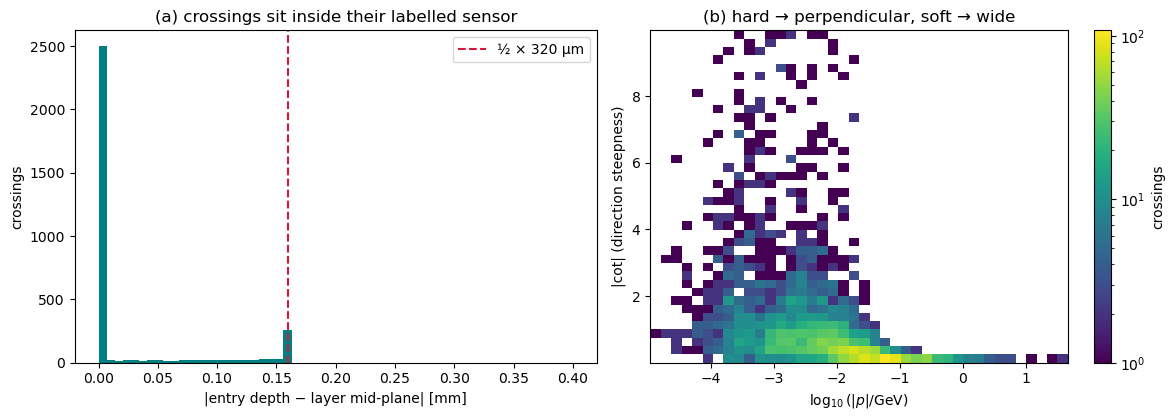

inward-going (toward smaller radius): 645;  outward-going: 2572  — momentum direction gives each the correct cot sign


In [5]:
cen = centers[layer]
resid = np.abs(depthw - cen)
cotmag = np.sqrt(cota**2 + cotb**2)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].hist(resid, bins=np.linspace(0, 0.4, 60), color='teal'); ax[0].axvline(0.16, color='crimson', ls='--', label='½ × 320 µm')
ax[0].set_xlabel('|entry depth − layer mid-plane| [mm]'); ax[0].set_ylabel('crossings'); ax[0].set_title('(a) crossings sit inside their labelled sensor'); ax[0].legend()
mm = (p_GeV>0)&np.isfinite(cotmag)&(cotmag<10)
hb = ax[1].hist2d(np.log10(p_GeV[mm]), cotmag[mm], bins=[40,40], cmap='viridis', norm=LogNorm())
fig.colorbar(hb[3], ax=ax[1], label='crossings')
ax[1].set_xlabel(r'$\log_{10}(|p|/\mathrm{GeV})$'); ax[1].set_ylabel('|cot| (direction steepness)'); ax[1].set_title('(b) hard → perpendicular, soft → wide')
plt.tight_layout(); plt.show()
nin = int(np.sum(np.array([s['flipped'] for s in segs])==0)); nout = len(segs)-nin
print(f'inward-going (toward smaller radius): {nin};  outward-going: {nout}  — momentum direction gives each the correct cot sign')

## 7. The hand-off — the per-crossing record schema

The validated records are serialized to plain `.json`/`.csv` tables. The full chain:

`SimTrackerHit` (Geant4) → `extract_trackermom.py` → `trackermom_*.npz` → `build_segments_C`
→ per-crossing records → `write_intermediate` → **`.json` + `.csv`**.

**The intermediate `.npz`** (`extract_trackermom.py`) holds, per tracker hit (positions in mm,
momenta in GeV): `thx, thy, thz` (global position), `tpx, tpy, tpz` (momentum), `tpath` (path
length in the sensor), `ttime` (ns), `tedep` (deposited energy), `tcellID`, and `tmc` (index
into the MCParticle arrays). The full MCParticle cascade (`pdg, mass, px, py, pz`, vertices)
is stored alongside for context and validation.

**The per-crossing record** — one dict per crossing from `build_segments_C`:

| field | type | units | meaning |
|---|---|---|---|
| `track_id` | int | — | index of the producing MCParticle |
| `layer_id` | int | 0–29 | silicon layer (0 = front) |
| `pdg` | int | — | particle type (PDG code) |
| `p_GeV` | float | GeV | real momentum magnitude at the crossing, √(tpx²+tpy²+tpz²) — not the production value |
| `entry_u`, `entry_v` | float | mm | local impact point (u across the pitch, v along cylinder-z); energy-weighted mid-crossing, ≈ mid-plane |
| `cot_alpha`, `cot_beta` | float | — | direction slopes p_u/p_w, p_v/p_w |
| `flipped` | int | 0/1 | 1 = outward-going (dw ≥ 0), 0 = inward-going (backscatter) |
| `sensor_normal_phi` | float | rad | the sensor face's outward-normal azimuth |
| `depth_w_mm` | float | mm | perpendicular depth of the impact point |
| `energy_dep_GeV` | float | GeV | energy deposited in this crossing |
| `n_steps` | int | — | 1 (the tracker action already combines a crossing's steps) |
| `time_ns` | float | ns | crossing time |
| `variant` | str | — | 'C' (tracker readout) |
| `flags` | str | — | provenance ('tracker_hit') |

Downstream consumers reformat these however their tool requires — the **`pixelav-inputs`**
branch of this repository, for example, serializes exactly these records into PIXELAV's
input-deck format for our collaborators. The cell below writes the tables and prints the
first rows.


In [6]:
models_dir = os.path.dirname(_find('trackermom_gamma50_1evt.npz'))
out_prefix = os.path.join(models_dir, 'sensor_crossings_gamma50_1evt')
jpath, cpath = sc.write_intermediate(segs, out_prefix)
print(f'wrote {len(segs)} crossing records -> {os.path.basename(jpath)}, {os.path.basename(cpath)}')
print('first rows of the CSV:')
for ln in open(cpath).read().splitlines()[:4]:
    print('  ', ln[:150])


wrote 3217 crossing records -> sensor_crossings_gamma50_1evt.json, sensor_crossings_gamma50_1evt.csv
first rows of the CSV:
   track_id,layer_id,pdg,p_GeV,entry_u,entry_v,cot_alpha,cot_beta,flipped,sensor_normal_phi,depth_w_mm,energy_dep_GeV,n_steps,time_ns,variant,flags
   1,8,11,46.8992919921875,0.00016671580662463162,-4.556476577411556e-05,0.00011181959257310972,-3.7477857425849126e-05,1,1.5707963267948966,1297.0099999
   1,9,11,35.28330993652344,0.0005199955419075863,0.00018599573537507127,-6.720234587408416e-05,0.00019763669731258544,1,1.5707963267948966,1300.75999999
   1,10,11,1.1318080425262451,-6.628520364674344e-05,0.0022913868837579838,0.002306946623249554,0.0021941019592287793,1,1.5707963267948966,1304.509999999


## 8. The two readouts are one shower, and the deposit is a real MIP

Every check above is *internal* self-consistency of the tracker readout. The two strongest checks are external to it. The calo run (notebook 07) and this tracker run share **seed 424242**, so they are the *same shower* read out two ways: if the SD change is truly a passive observer, (1) their MCParticle cascades are byte-identical, (2) their crossing counts differ only by *definition* (the tracker writes one `SimTrackerHit` per sensor *entry* while the calo groups a particle's steps per layer, so re-entrant tracks are counted differently), and (3) the two crossings-per-layer profiles trace the same longitudinal shower as notebook 05's energy profile. All shown here:

(1) MCParticle cascade: 78,270 particles, same PDG list = True, max|dp| = 0.0e+00 GeV  ->  calo & tracker read out ONE shower


(2) crossings on that shower:  tracker (06) = 3217   calo (07) = 2535   diff = 682
    the diff is entirely re-entries: 682 (particle, layer) pairs the tracker records more than once -- one SimTrackerHit per sensor ENTRY -- while the calo groups a particle's steps per layer into one crossing.
    pairs seen by only one readout: tracker-only = 0, calo-only = 0  ->  the two agree on WHICH sensors each particle hits; they differ only in counting re-entries.


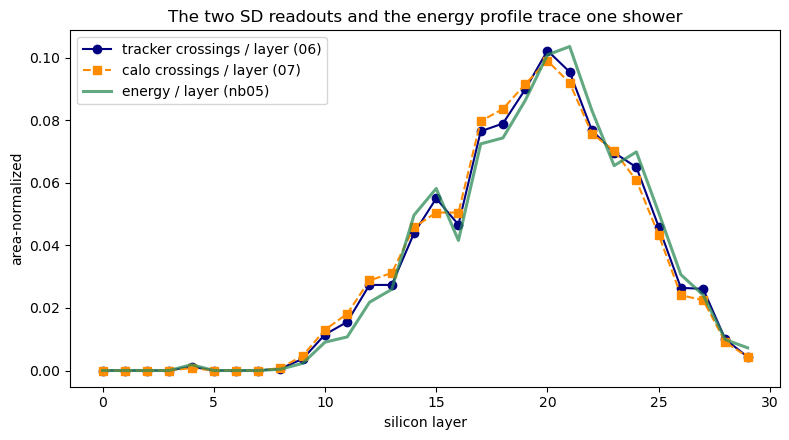

(3) longitudinal-shape correlation with the energy profile:  tracker = 0.995   calo = 0.987   (1.000 = identical shape)
(4) crossing origin:  88% entering tracks born outside the Si (median KE 19 MeV),  12% delta rays born inside a sensor (median KE 0.5 MeV)


In [7]:
import os
def _fcp():
    for b in ['../models', 'models', os.path.join(os.environ.get('CALOMAPS_HOME', '..'), 'models')]:
        p = os.path.join(b, 'fullcascade_gamma50_1evt.npz')
        if os.path.exists(p): return p
    return None
_p = _fcp()
if _p is None:
    print('fullcascade_gamma50_1evt.npz not found -- run the notebook-05 pipeline (extract_cascade.py); skipping cross-readout overlay')
else:
    dF = np.load(_p, allow_pickle=True)
    # (1) the two runs are the SAME shower: byte-identical MCParticle cascade
    same = np.array_equal(dF['pdg'], dT['pdg'])
    mdp = max(np.abs(dF['px'] - dT['px']).max(), np.abs(dF['py'] - dT['py']).max(), np.abs(dF['pz'] - dT['pz']).max())
    print(f"(1) MCParticle cascade: {len(dT['pdg']):,} particles, same PDG list = {same}, max|dp| = {mdp:.1e} GeV  ->  calo & tracker read out ONE shower")
    # (2) count reconciliation: same shower, two definitions of a crossing
    from collections import Counter
    segsA, _ = sc.build_segments_A(dF)
    kT = Counter((s['track_id'], s['layer_id']) for s in segs)
    kA = Counter((s['track_id'], s['layer_id']) for s in segsA)
    reentry = sum(v - 1 for v in kT.values() if v > 1)
    onlyT = sum(kT[k] for k in kT if k not in kA); onlyA = sum(kA[k] for k in kA if k not in kT)
    print(f"(2) crossings on that shower:  tracker (06) = {len(segs)}   calo (07) = {len(segsA)}   diff = {len(segs) - len(segsA)}")
    print(f"    the diff is entirely re-entries: {reentry} (particle, layer) pairs the tracker records more than once -- one SimTrackerHit per sensor ENTRY -- while the calo groups a particle's steps per layer into one crossing.")
    print(f"    pairs seen by only one readout: tracker-only = {onlyT}, calo-only = {onlyA}  ->  the two agree on WHICH sensors each particle hits; they differ only in counting re-entries.")
    # (3) three independent longitudinal profiles trace the same shower
    centers = sc.si_layer_centers()
    profT = np.bincount([s['layer_id'] for s in segs],  minlength=30).astype(float)
    profA = np.bincount([s['layer_id'] for s in segsA], minlength=30).astype(float)
    phin = sc.face_phi(dF['csx'], dF['csy']); wdep = dF['csx'] * np.cos(phin) + dF['csy'] * np.sin(phin)
    layE = np.argmin(np.abs(wdep[:, None] - centers[None, :]), axis=1)
    profE = np.zeros(30); np.add.at(profE, layE, dF['cE'])
    L = np.arange(30)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(L, profT / profT.sum(), 'o-', color='navy', label='tracker crossings / layer (06)')
    ax.plot(L, profA / profA.sum(), 's--', color='darkorange', label='calo crossings / layer (07)')
    ax.plot(L, profE / profE.sum(), '-', color='seagreen', lw=2.2, alpha=0.75, label='energy / layer (nb05)')
    ax.set_xlabel('silicon layer'); ax.set_ylabel('area-normalized'); ax.legend()
    ax.set_title('The two SD readouts and the energy profile trace one shower'); plt.tight_layout(); plt.show()
    cT = np.corrcoef(profT / profT.sum(), profE / profE.sum())[0, 1]
    cA = np.corrcoef(profA / profA.sum(), profE / profE.sum())[0, 1]
    print(f"(3) longitudinal-shape correlation with the energy profile:  tracker = {cT:.3f}   calo = {cA:.3f}   (1.000 = identical shape)")
    # (4) where the crossings are born: entering tracks vs in-sensor delta rays
    tmc = dT['tmc'].astype(int); ch = sc.is_charged(dT['pdg'][tmc])
    vx, vy = dT['vsx'][tmc], dT['vsy'][tmc]; pv = sc.face_phi(vx, vy); wv = vx * np.cos(pv) + vy * np.sin(pv)
    ins = np.min(np.abs(wv[:, None] - centers[None, :]), axis=1) < sc.SI_THICK_MM / 2
    KE = (dT['E'] - dT['mass'])[tmc] * 1e3
    print(f"(4) crossing origin:  {(~ins)[ch].mean() * 100:.0f}% entering tracks born outside the Si (median KE {np.median(KE[ch & ~ins]):.0f} MeV),  {ins[ch].mean() * 100:.0f}% delta rays born inside a sensor (median KE {np.median(KE[ch & ins]):.1f} MeV)")


### 8b. Absolute scale — the crossings deposit a silicon MIP

The one check that appeals to physics *outside* this pipeline: a relativistic track crossing the full 320 um sensor must deposit the silicon **MIP** — a Landau distribution whose most-probable value is ~85 keV, exactly the MIP the calo pipeline (nb01/nb02) is normalized to. `Geant4TrackerWeightedAction` records both `eDep` and `pathLength` per crossing, so we can show it directly (and confirm the SD integrates the full sensor depth, not a single pixel):

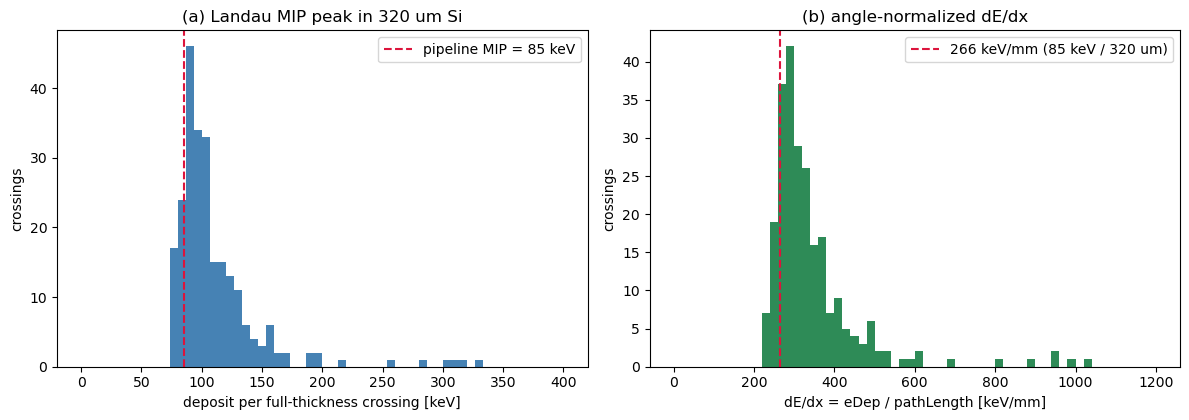

full-thickness crossings n = 244:  Landau MPV ~ 90 keV, median = 100, mean = 114 keV
-> the MPV lands on the 85 keV MIP the calo pipeline (nb01/nb02) is built on; MPV < median < mean is the Landau tail.
This ties the SD deposit to an ABSOLUTE physical scale -- external to any reconstruction in this notebook.


In [8]:
# The one EXTERNAL check: the energy each crossing leaves in the 320 um sensor must be the
# silicon MIP -- a Landau with most-probable value ~85 keV, the value nb01/nb02 normalize to.
tp = np.sqrt(dT['tpx']**2 + dT['tpy']**2 + dT['tpz']**2)      # |p| per SimTrackerHit (GeV)
tpath = np.asarray(dT['tpath']); tedep = np.asarray(dT['tedep']) * 1e6   # pathLength mm; deposit keV
rel = tp > 0.1                                                # relativistic (>100 MeV): on the MIP plateau
full = rel & (tpath > 0.30) & (tpath < 0.40)                 # near-perpendicular, ~full 320 um traversal
MIP_keV = 85.0
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].hist(tedep[full], bins=60, range=(0, 400), color='steelblue')
ax[0].axvline(MIP_keV, color='crimson', ls='--', label=f'pipeline MIP = {MIP_keV:.0f} keV')
ax[0].set_xlabel('deposit per full-thickness crossing [keV]'); ax[0].set_ylabel('crossings')
ax[0].set_title('(a) Landau MIP peak in 320 um Si'); ax[0].legend()
dedx = tedep[rel] / tpath[rel]
ax[1].hist(dedx, bins=60, range=(0, 1200), color='seagreen')
ax[1].axvline(MIP_keV / 0.32, color='crimson', ls='--', label=f'{MIP_keV / 0.32:.0f} keV/mm (85 keV / 320 um)')
ax[1].set_xlabel('dE/dx = eDep / pathLength [keV/mm]'); ax[1].set_ylabel('crossings')
ax[1].set_title('(b) angle-normalized dE/dx'); ax[1].legend()
plt.tight_layout(); plt.show()
h, e = np.histogram(tedep[full], bins=60, range=(0, 400)); mpv = 0.5 * (e[np.argmax(h)] + e[np.argmax(h) + 1])
print(f"full-thickness crossings n = {int(full.sum())}:  Landau MPV ~ {mpv:.0f} keV, median = {np.median(tedep[full]):.0f}, mean = {np.mean(tedep[full]):.0f} keV")
print(f"-> the MPV lands on the {MIP_keV:.0f} keV MIP the calo pipeline (nb01/nb02) is built on; MPV < median < mean is the Landau tail.")
print("This ties the SD deposit to an ABSOLUTE physical scale -- external to any reconstruction in this notebook.")


## 9. The shower behind these crossings — the full particle cascade

Sections 4–8 are a *reduction*: one record per sensor crossing. This section restores the full picture those records come from — the complete Geant4 shower of ~78,000 particles for this one 50 GeV photon, the same event notebook [05](05_shower_4vectors.ipynb) examines, reproduced here so this notebook stands on its own. Every plot below is the particle-level *origin* of something you have already seen in the crossings:

- the **composition** and **energy spectrum** are why the crossing-momentum spectrum (§4c) peaks at a few MeV — the soft sea is absorbed in the tungsten before it reaches silicon;
- the **opening-angle-vs-energy** trend is the particle-level source of the per-crossing `cot` vs `|p|` pattern (§6);
- the **cascade tree** is the branching structure that populates the 30 layers (§4d).

Because the tracker readout gave us the *real* per-crossing momentum (§5), these production-level kinematics connect directly to the momenta we validated there. (Notebook 05 presents this same cascade as its main subject; notebook [07](07_sensor_crossings_calo.ipynb) shows it from the calorimeter-readout side.)

In [9]:
# --- the full particle cascade behind the crossings (same event, from the tracker npz) ---
# the tracker readout carries the whole MCParticle shower alongside the crossings, so this
# notebook can tell the complete shower story on its own. The "silicon hits" used by the
# deposition/shape plots below are the per-crossing tracker hits themselves (one per sensor
# crossing) -- there is no separate calorimeter-hit collection in this run.
pdg, mass, E = dT["pdg"], dT["mass"], dT["E"]
px, py, pz = dT["px"], dT["py"], dT["pz"]
pex, pey, pez = dT["pex"], dT["pey"], dT["pez"]
vsx, vsy, vsz = dT["vsx"], dT["vsy"], dT["vsz"]
vex, vey, vez = dT["vex"], dT["vey"], dT["vez"]
dbeg, dend, dau = dT["dbeg"], dT["dend"], dT["dau"]
hx, hy, hz, he = dT["thx"], dT["thy"], dT["thz"], dT["tedep"]   # per-crossing Si deposits (mm, GeV)
print(f"full cascade behind these crossings: {len(pdg):,} MCParticles, "
      f"{len(hx):,} silicon crossings, {he.sum():.3f} GeV deposited (sampling ~{he.sum()/50:.2%})")

full cascade behind these crossings: 78,270 MCParticles, 3,241 silicon crossings, 0.531 GeV deposited (sampling ~1.06%)


### Composition

An EM shower grows by two interleaved processes: **pair production** (γ → e⁺e⁻ in a nucleus's
field) and **bremsstrahlung** (e± radiating γ). They feed each other, so the cascade is
overwhelmingly electrons, positrons and photons.

**Why far more electrons than positrons?** Pair production makes e⁺ and e⁻ in equal numbers,
but electrons get three *extra* sources that create no positrons: **ionization / delta rays**
(any charged particle knocking atomic electrons loose), **Compton scattering**, and the
**photoelectric effect** (both eject atomic electrons). Meanwhile positrons are *removed* by
**annihilation** (e⁺ → γγ) at the end of their range. Net effect: e⁻ outnumber e⁺ by about an
order of magnitude here — a real, expected asymmetry, not a bug.

The handful of neutrons, protons and excited tungsten nuclei (PDG `100074xxxx`) come from
**photonuclear** interactions of shower photons with the W absorber.

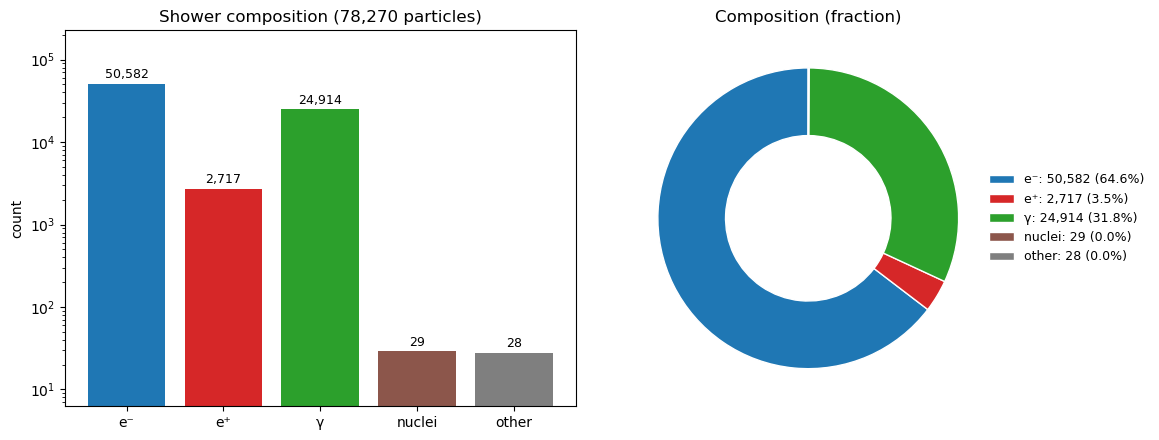

top PDG codes: [(11, 50582), (22, 24914), (-11, 2717), (2112, 24), (2212, 4), (1000741830, 4), (1000741820, 4), (1000741810, 4)]


In [10]:
uniq, counts = np.unique(pdg, return_counts=True)
order = np.argsort(-counts)

# Group: e-, e+, gamma, nuclei (|pdg|>1e9), other
groups = {"e⁻": 0, "e⁺": 0, "γ": 0, "nuclei": 0, "other": 0}
for p, c in zip(uniq, counts):
    if p == 11: groups["e⁻"] += c
    elif p == -11: groups["e⁺"] += c
    elif p == 22: groups["γ"] += c
    elif abs(p) > 1_000_000_000: groups["nuclei"] += c
    else: groups["other"] += c
g = {k: v for k, v in groups.items() if v}
cols = ["#1f77b4", "#d62728", "#2ca02c", "#8c564b", "#7f7f7f"][:len(g)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
bars = ax[0].bar(g.keys(), g.values(), color=cols)
ax[0].set_yscale("log"); ax[0].set_ylabel("count")
ax[0].set_title(f"Shower composition ({len(pdg):,} particles)")
ax[0].bar_label(bars, fmt="{:,.0f}", padding=2, fontsize=9)
ax[0].margins(y=0.2)

# Pie: labels go in a legend (avoids overlap on the tiny nuclei/other slices);
# percentages are drawn only on slices large enough to read.
total = sum(g.values())
wedges, _ = ax[1].pie(list(g.values()), colors=cols, startangle=90,
                      wedgeprops=dict(width=0.45, edgecolor="w"))
ax[1].set_title("Composition (fraction)")
ax[1].legend(wedges, [f"{k}: {v:,} ({v/total:.1%})" for k, v in g.items()],
             loc="center left", bbox_to_anchor=(0.95, 0.5), frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print("top PDG codes:", [(int(uniq[i]), int(counts[i])) for i in order[:8]])

### Energy spectrum

**Left — the spectrum itself.** Each shower generation roughly *halves* the energy while
*doubling* the particle count, so the number of secondaries climbs steeply toward low energy:
a near-power-law fall spanning many decades. Multiplication stops once particles drop below
the ~MeV scale (e± can no longer pair-produce or radiate efficiently), so the cascade "dies"
into a sea of soft e±/γ. The few entries far to the right are the *top* of the cascade: the
primary and its first-conversion e⁺e⁻, carrying tens of GeV.

**The three species have distinctly different shapes:**
- **γ (green)** reaches the **lowest energies** — down to ~1 keV here. Photons keep being made
  throughout the cascade (bremsstrahlung, atomic de-excitation) and, being massless, their
  *total* energy *is* their kinetic energy, so there is no floor. Below ~1 MeV they can no
  longer pair-produce, so they stop multiplying but linger as a soft sea until photoelectric
  absorption finally removes them. The 0.511 MeV spike (next paragraph) rides on top.
- **e⁻ (blue)** falls steeply and sits **above e⁺ at every energy** (the extra electron-only
  sources noted in the composition above). Both e± spectra **stop dead at 0.511 MeV**: a particle's *total*
  energy E = √(p²+m²) can never fall below its rest mass mₑc² = 0.511 MeV, so a stopped
  electron (KE → 0) piles up right at that edge. It is the *same* 0.511 MeV as the photon line —
  same mₑc², different reason (rest-mass floor vs annihilation photons).
- **e⁺ (red)** tracks e⁻ at high energy (pair production is symmetric) but is depleted toward
  the floor — stopped positrons **annihilate**, which is what feeds the photon line.

**The sharp photon spike at 0.511 MeV is the positron-annihilation line** — a real spectral
*line*, not a threshold. Every positron, once it slows to rest in the dense W/Si, annihilates
with an atomic electron (**e⁺e⁻ → 2γ**), emitting two back-to-back photons each carrying
exactly the electron rest energy, mₑc² = 511 keV. With thousands of positrons stopping in the
calorimeter these monoenergetic photons pile up: here **~20% of all photons** sit within a few
percent of 511 keV. (The dotted marker sits at mₑc² for exactly this reason.)

**Right — where the energy actually is.** The cumulative curve shows the central tension of
calorimetry: although almost all *particles* are soft, almost all the *energy* is carried by
the handful of *hard* particles near the top of the cascade. Yet the measurable **signal**
(the silicon hits) is made by the enormous number of soft particles ionizing the sensors — so
a good calorimeter has to faithfully collect charge from the soft sea, even though the energy
"lives" in a few hard tracks.

**Why nuclei are excluded from this plot.** The quantity plotted is *total* energy
E = √(p² + m²). For e±/γ the rest mass is negligible, so E is essentially the kinematic
(shower-relevant) energy. But a recoiling nucleus — e.g. a tungsten ion, m ≈ 173 GeV — is
nearly at rest with only keV–MeV of kinetic energy; its *total* energy is almost entirely rest
mass, which would plant spurious ~170-GeV entries far off the right edge and misrepresent the
shower.

> ⚠️ **A 50 GeV photon, yet "particles" at 173 GeV?** Not an energy-budget violation. That
> ~173 GeV is a tungsten nucleus's **rest mass** (E = mc², ~184 nucleons) — it was already
> sitting in the absorber before the event, *not* energy delivered by the photon. The photon
> only gives the nucleus a **≤ MeV recoil**; its 50 GeV is fully conserved, spent on the
> *kinetic* energies of the shower. The kinetic-energy plot below makes this obvious: the
> nuclei drop to keV–MeV, where they belong.

(The nuclei are also a negligible handful and don't drive the EM cascade.)

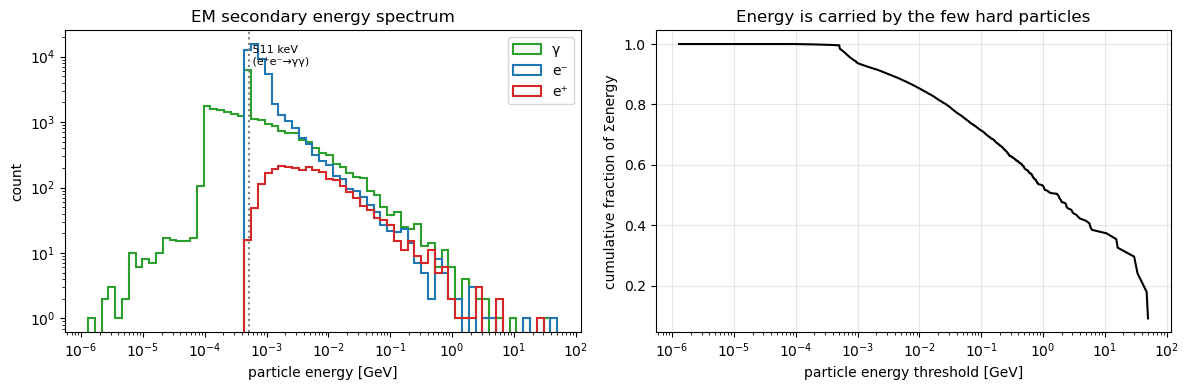

median EM particle energy: 0.66 MeV
# EM particles above 1 GeV: 43 (0.05%)
photons within +/-5% of 511 keV: 21.8%  (expected 2*N(e+)/N(gamma) = 21.8%: two annihilation photons per stopped positron)


In [11]:
em = (pdg == 11) | (pdg == -11) | (pdg == 22)
Eem = E[em]
Eem = Eem[Eem > 0]
assert Eem.size, "no EM (e/gamma) particles with E>0 in this event — energy-spectrum plot needs them"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bins = np.logspace(np.log10(max(Eem.min(), 1e-6)), np.log10(Eem.max()), 70)   # down to ~keV: show the full soft sea
for sel, lab, col in [(pdg == 22, "γ", "#2ca02c"), (pdg == 11, "e⁻", "#1f77b4"), (pdg == -11, "e⁺", "#d62728")]:
    es = E[sel]; es = es[es > 0]
    ax[0].hist(es, bins=bins, histtype="step", label=lab, color=col, lw=1.5)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("particle energy [GeV]"); ax[0].set_ylabel("count")
ax[0].set_title("EM secondary energy spectrum"); ax[0].legend()
ax[0].axvline(0.000511, ls=":", color="grey"); ax[0].text(0.000511, ax[0].get_ylim()[1]*0.3, " 511 keV\n (e⁺e⁻→γγ)", fontsize=8)

es = np.sort(Eem)[::-1]
ax[1].plot(es, np.cumsum(es)/es.sum(), color="black")
ax[1].set_xscale("log"); ax[1].set_xlabel("particle energy threshold [GeV]")
ax[1].set_ylabel("cumulative fraction of Σenergy"); ax[1].set_title("Energy is carried by the few hard particles")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"median EM particle energy: {np.median(Eem)*1000:.2f} MeV")
print(f"# EM particles above 1 GeV: {(Eem>1).sum():,} ({(Eem>1).mean():.2%})")
_g = E[pdg == 22]; _frac = np.mean(np.abs(_g - 0.000511) < 0.05 * 0.000511)
_exp = 2 * (pdg == -11).sum() / max((pdg == 22).sum(), 1)
print(f"photons within +/-5% of 511 keV: {_frac:.1%}  (expected 2*N(e+)/N(gamma) = {_exp:.1%}: two annihilation photons per stopped positron)")

### Kinetic energy — bringing the nuclei (and hadrons) back

The spectrum above used *total* energy E = √(p²+m²), which is why nuclei had to be dropped
(their E is almost all rest mass). The physically meaningful quantity for a slow, massive
recoil is the **kinetic energy** T = E − m. Plotted in T, every species sits at its true
kinematic energy — so we can show the *whole* particle inventory on one axis, including the
photonuclear neutrons, protons and tungsten nuclei, which land at keV–MeV (not ~170 GeV).

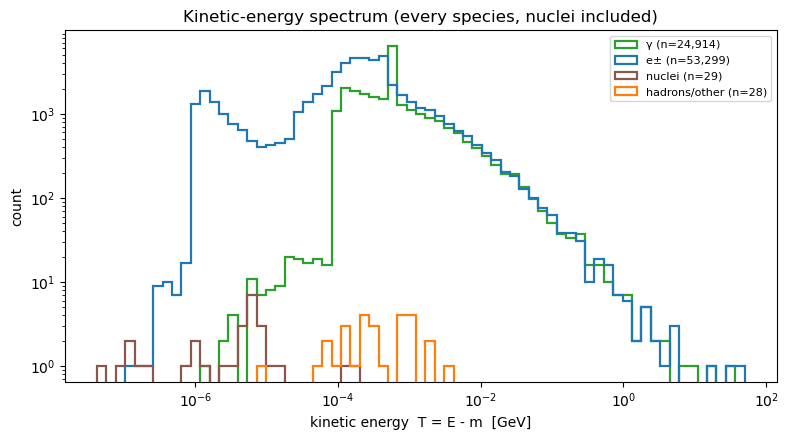

nuclei: n=29, kinetic energy 0.0 eV - 0.2 MeV
  ...their TOTAL energy E would be ~173 GeV (essentially all rest mass)


In [12]:
T = E - mass   # kinetic energy (GeV)
nuc = np.abs(pdg) > 1_000_000_000
groups = [(pdg == 22, "γ", "#2ca02c"), ((pdg == 11) | (pdg == -11), "e±", "#1f77b4"),
          (nuc, "nuclei", "#8c564b"),
          (~nuc & (pdg != 22) & (pdg != 11) & (pdg != -11), "hadrons/other", "#ff7f0e")]
Tpos = T[T > 0]
bins = np.logspace(np.log10(max(Tpos.min(), 1e-9)), np.log10(Tpos.max()), 70)

fig, ax = plt.subplots(figsize=(8, 4.5))
for sel, lab, col in groups:
    t = T[sel & (T > 0)]
    if t.size:
        ax.hist(t, bins=bins, histtype="step", lw=1.6, color=col, label=f"{lab} (n={int(sel.sum()):,})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("kinetic energy  T = E - m  [GeV]"); ax.set_ylabel("count")
ax.set_title("Kinetic-energy spectrum (every species, nuclei included)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
if nuc.any():
    print(f"nuclei: n={int(nuc.sum())}, kinetic energy {T[nuc].min()*1e6:.1f} eV - {T[nuc].max()*1e3:.1f} MeV")
    print(f"  ...their TOTAL energy E would be ~{mass[nuc].max():.0f} GeV (essentially all rest mass)")

### Longitudinal & radial development

The beam travels +y; the ECal front face is at r = 1264 mm. The calorimeter is a stack of
**tungsten-absorber / silicon-sensor** layers (from `my_custom_ecal.xml`): 20 layers of
2.5 mm W + 0.32 mm Si, then 10 layers of 5 mm W + 0.32 mm Si. The shaded **gray bands** in the
first two panels mark the tungsten slabs.

**Left — where particles are born (by species).** The production-vertex profile shows a *comb*
locked to the layers: far more secondaries are created **inside the tungsten** than in the thin
Si/air gaps. Tungsten is dense and high-Z, with a radiation length of only ~3.9 mm (for the
93%-tungsten alloy used here; notebook 01 §3b computes the full budget) versus
~94 mm for silicon — so pair production and bremsstrahlung (which *make* the new particles)
happen overwhelmingly in the absorber. That is the origin of the step-between-bins behaviour:
peaks sit in the gray W bands, dips in the gaps.

**Middle — where energy is measured.** This is built from the per-crossing **tracker deposits**
(the §4 crossings), which by construction sit in the silicon sensors — the tungsten is a passive
absorber with no readout. So the deposited-energy
points fall in the thin gaps *between* the W bands (the Si layers), never inside them; the
y-axis here samples only the silicon. As a geometry cross-check, the layer model puts the
deepest Si layer at y ≈ 1400.7 mm, exactly where the last hits are. This panel simply sums the deposited energy per layer; each tracker hit does carry an
MCParticle link (used in §5), but the longitudinal view does not need it.

**Right — radial (lateral) profile.** Perpendicular to the beam, energy lands in a tight core
that falls off with transverse radius √(x²+z²) — the lateral spread set by multiple scattering
and the EM Molière radius. The printout reports the 90% / 95% energy-containment radii.

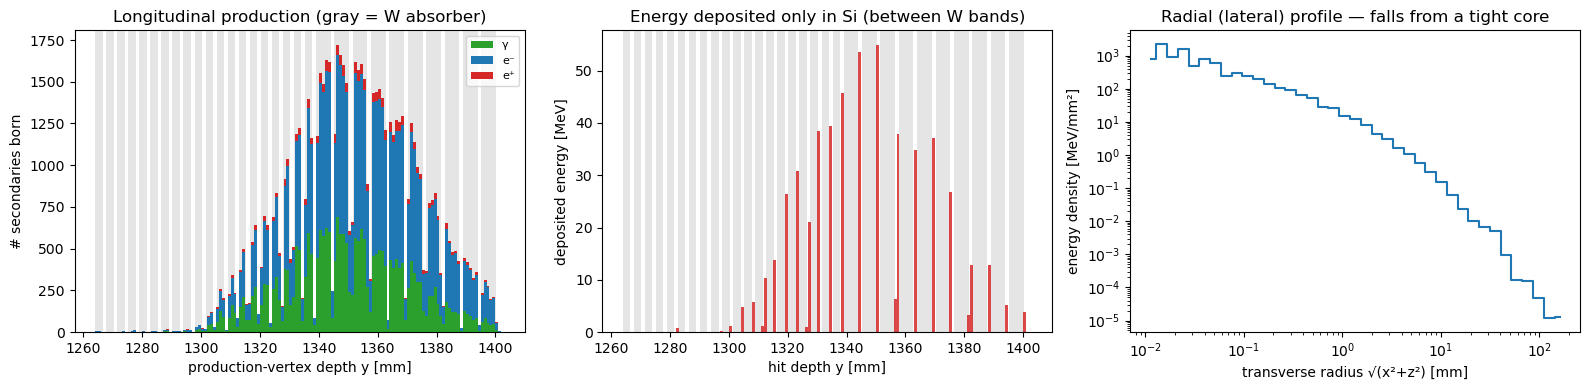

Si-layer model: 30 layers, first y=1266.9 mm, last y=1400.7 mm (deepest hit at y=1400.8 mm — matches)
90% of deposited energy within transverse radius 12.5 mm
95% of deposited energy within transverse radius 23.8 mm


In [13]:
# --- W/Si layer model (geometry/my_custom_ecal.xml; ECal front rmin = 1264 mm) ---
rmin = 1264.0
w_bands, si_pos, yy = [], [], rmin
for nrep, wthick in [(20, 2.5), (10, 5.0)]:
    pitch = wthick + 0.25 + 0.32 + 0.05 + 0.30 + 0.33    # W + air + Si + Cu + Kapton + air (mm)
    for _ in range(nrep):
        w_bands.append((yy, yy + wthick))                # tungsten slab
        si_pos.append(yy + wthick + 0.25 + 0.16)         # silicon-layer centre
        yy += pitch
def draw_W(a):
    for lo, hi in w_bands:
        a.axvspan(lo, hi, color="0.6", alpha=0.25, lw=0)

species = [(pdg == 22, "γ", "#2ca02c"), (pdg == 11, "e⁻", "#1f77b4"), (pdg == -11, "e⁺", "#d62728")]
dbins = np.linspace(rmin, 1403, 140)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# (a) production by species, stacked, with the W bands behind
draw_W(ax[0])
inwin = (vsy > rmin) & (vsy < 1403)
ax[0].hist([vsy[m & inwin] for m, _, _ in species], bins=dbins, stacked=True,
           label=[lab for _, lab, _ in species], color=[c for _, _, c in species])
ax[0].set_xlabel("production-vertex depth y [mm]"); ax[0].set_ylabel("# secondaries born")
ax[0].set_title("Longitudinal production (gray = W absorber)"); ax[0].legend(fontsize=8)

# (b) energy deposition (hits) -- only in Si, i.e. in the gaps between the W bands
draw_W(ax[1])
ax[1].hist(hy, bins=dbins, weights=he * 1000, color="#d62728", alpha=0.85)
ax[1].set_xlabel("hit depth y [mm]"); ax[1].set_ylabel("deposited energy [MeV]")
ax[1].set_title("Energy deposited only in Si (between W bands)")

# (c) radial / lateral profile -- energy DENSITY (per unit area) so it falls from the core
rho = np.hypot(hx, hz)   # transverse distance from the +y beam axis
rb = np.logspace(np.log10(max(rho[rho > 0].min(), 1e-2)), np.log10(rho.max() + 1), 40)
e_shell, _ = np.histogram(rho, bins=rb, weights=he * 1000)        # MeV per annular shell
area = np.pi * (rb[1:]**2 - rb[:-1]**2)                           # shell area, mm^2
rc = np.sqrt(rb[1:] * rb[:-1])
ax[2].plot(rc, e_shell / area, drawstyle="steps-mid", color="#1f77b4")
ax[2].set_xscale("log"); ax[2].set_yscale("log")
ax[2].set_xlabel("transverse radius √(x²+z²) [mm]"); ax[2].set_ylabel("energy density [MeV/mm²]")
ax[2].set_title("Radial (lateral) profile — falls from a tight core")
plt.tight_layout(); plt.show()

print(f"Si-layer model: {len(si_pos)} layers, first y={si_pos[0]:.1f} mm, last y={si_pos[-1]:.1f} mm "
      f"(deepest hit at y={hy.max():.1f} mm — matches)")
o = np.argsort(rho); cumE = np.cumsum(he[o]) / he.sum(); rsort = np.sort(rho)
for frac in (0.90, 0.95):
    print(f"{frac:.0%} of deposited energy within transverse radius {rsort[np.searchsorted(cumE, frac)]:.1f} mm")

### Shower shape — transverse spread and 3D view

**These plots use the per-crossing silicon deposits (the tracker hits from §4), not the truth particles.** They show
where energy actually lands in the sensors — the *measurable* shower image — as opposed to the
particle-level views above, which come from the MCParticle truth. (So there
is no per-particle-type breakdown here: a hit only knows its position and deposited energy, not
which particle made it — this view just needs where the energy landed.)

Transverse coordinates are x and z (the beam is +y); the shower is narrow near the front and
spreads with depth. Hit positions are colored by deposited energy.

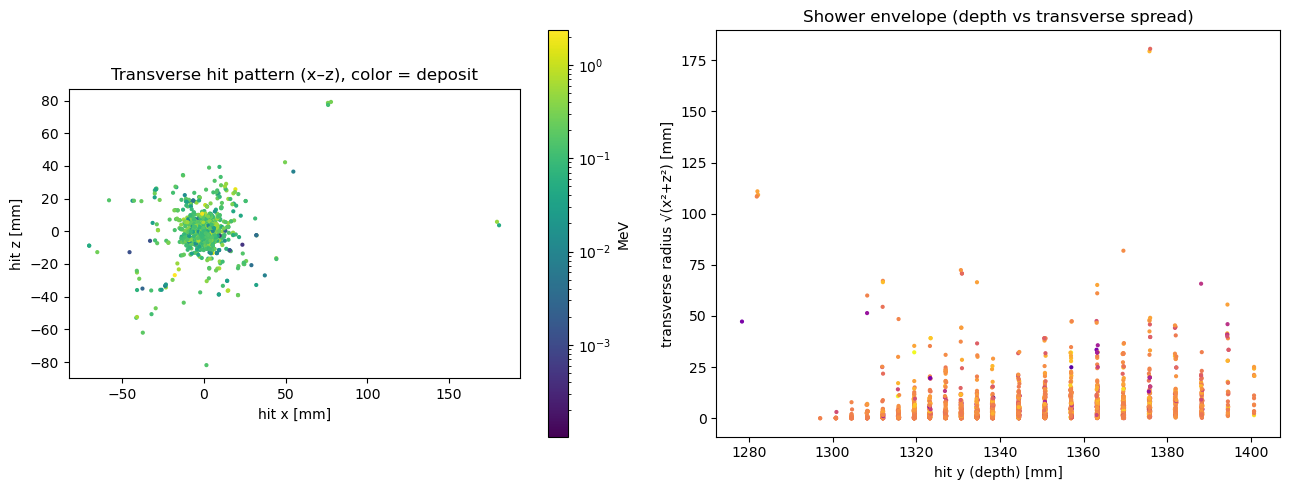

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sc = ax[0].scatter(hx, hz, c=he*1000, s=4, cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
ax[0].set_xlabel("hit x [mm]"); ax[0].set_ylabel("hit z [mm]"); ax[0].set_aspect("equal")
ax[0].set_title("Transverse hit pattern (x–z), color = deposit"); plt.colorbar(sc, ax=ax[0], label="MeV")

rt = np.hypot(hx, hz)
ax[1].scatter(hy, rt, c=he*1000, s=4, cmap="plasma", norm=plt.matplotlib.colors.LogNorm())
ax[1].set_xlabel("hit y (depth) [mm]"); ax[1].set_ylabel("transverse radius √(x²+z²) [mm]")
ax[1].set_title("Shower envelope (depth vs transverse spread)")
plt.tight_layout(); plt.show()

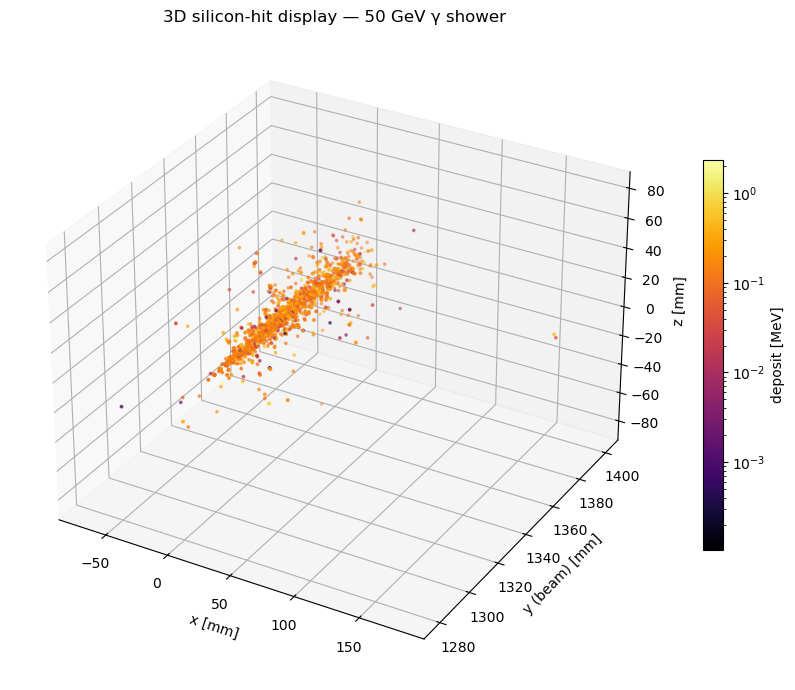

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sub = slice(None) if len(hx) < 20000 else np.random.default_rng(0).choice(len(hx), 20000, replace=False)
p = ax.scatter(hx[sub], hy[sub], hz[sub], c=he[sub]*1000, s=3, cmap="inferno",
               norm=plt.matplotlib.colors.LogNorm())
ax.set_xlabel("x [mm]"); ax.set_ylabel("y (beam) [mm]"); ax.set_zlabel("z [mm]")
ax.set_title("3D silicon-hit display — 50 GeV γ shower")
fig.colorbar(p, label="deposit [MeV]", shrink=0.6)
plt.tight_layout(); plt.show()

### Momentum directions

A particle's opening angle is a competition between **relativistic beaming** and **multiple
scattering**. Bremsstrahlung and pair production emit their products within a characteristic
angle ~ mₑc²/E of the parent's direction (higher energy ⇒ tighter cone), so freshly-made *hard*
particles are sharply forward. But once a particle slows to the ~MeV scale, multiple Coulomb
scattering randomises its direction — and since the cascade is overwhelmingly soft (see the energy spectrum above), the
*bulk* of particles end up nearly isotropic. The three panels disentangle this.

**Left — opening angle, by species.** Compare each curve to the dashed reference an *isotropic*
3-D distribution would give (dN/dθ ∝ sinθ, peaking at θ = 90°). The three species look
strikingly different, and the difference is all **production mechanism**:
- **e⁺ (red) are the most forward** — median ≈ 17°, ~35% within 10° of the beam. Positrons are
  made *only* by pair production, which is forward-beamed; there is no positron analogue of
  knock-out electrons, so they stay close to their forward origin.
- **e⁻ (blue) are the widest** — median ≈ 73°, peaking near 90° and with ~36% going *backward*.
  Electrons get the extra wide-angle sources noted above — **delta rays** kicked sideways by
  ionisation, plus Compton and photoelectric electrons — and the huge soft-electron sea is
  fully multiple-scattered, so it traces almost exactly the isotropic sinθ shape.
- **γ (green) sit in between** — median ≈ 49°, with a sharp forward spike. Bremsstrahlung
  photons are beamed forward, while soft photons and the **isotropic 511 keV annihilation
  photons** (emitted every which way by stopped positrons) fill in all the other angles.

**Middle — azimuthal symmetry.** The azimuth φ in the transverse x–z plane is **flat**, as it
must be: beam on-axis, no magnetic field, so no preferred transverse direction. A non-flat φ
would flag a geometry or bookkeeping bug — a cheap but genuine validation.

**Right — collimation vs energy.** The cleanest statement of the beaming-vs-scattering
competition: the median opening angle plunges from ~70° for the soft sea (E < 10 MeV) to
**0.08°** for E > 1 GeV (essentially every hard track is within 10° of the beam). A particle's
angle is set almost entirely by its energy. *This per-track opening angle — direction as a function of how hard the particle is — is the
particle-level origin of the per-crossing `cot` vs `|p|` pattern we validated in §6.*

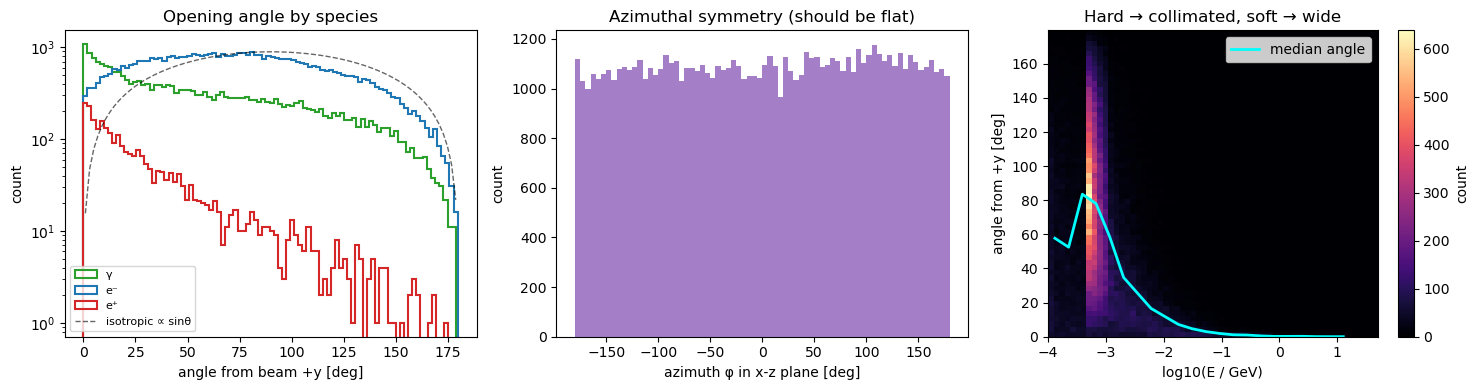

median opening angle: all = 64.7°, E>1 GeV = 0.08°, E<10 MeV = 67.5°
  e-    median = 73.4°, within 10deg =   4%, backward(>90deg) =  36%
  e+    median = 17.0°, within 10deg =  35%, backward(>90deg) =   6%
  gamma median = 48.6°, within 10deg =  17%, backward(>90deg) =  26%


In [16]:
pmag = np.sqrt(px**2 + py**2 + pz**2)
good = (pmag > 0) & em
theta = np.degrees(np.arccos(np.clip(py[good] / pmag[good], -1, 1)))   # angle from +y beam
phi   = np.degrees(np.arctan2(pz[good], px[good]))                     # azimuth in the x-z plane
Eg, gpdg = E[good], pdg[good]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# (a) opening angle, split by species, against an isotropic (sin theta) reference
for sel, lab, col in [(gpdg==22,"γ","#2ca02c"), (gpdg==11,"e⁻","#1f77b4"), (gpdg==-11,"e⁺","#d62728")]:
    ax[0].hist(theta[sel], bins=90, histtype="step", lw=1.5, color=col, label=lab)
_cnt, _ed = np.histogram(theta[gpdg==11], bins=90); _tc = 0.5*(_ed[:-1]+_ed[1:])
_ref = np.sin(np.radians(_tc)); _ref *= _cnt.max()/_ref.max()
ax[0].plot(_tc, _ref, "k--", lw=1, alpha=0.6, label="isotropic ∝ sinθ")
ax[0].set_yscale("log"); ax[0].set_xlabel("angle from beam +y [deg]"); ax[0].set_ylabel("count")
ax[0].set_title("Opening angle by species"); ax[0].legend(fontsize=8)
# (b) azimuthal symmetry (should be flat)
ax[1].hist(phi, bins=72, color="#9467bd", alpha=0.85)
ax[1].set_xlabel("azimuth φ in x-z plane [deg]"); ax[1].set_ylabel("count"); ax[1].set_ylim(bottom=0)
ax[1].set_title("Azimuthal symmetry (should be flat)")
# (c) collimation vs energy, with a median profile
le = np.log10(np.clip(Eg, 1e-4, None))
h = ax[2].hist2d(le, theta, bins=[60, 60], cmap="magma")
xb = np.linspace(le.min(), le.max(), 25); xc = 0.5*(xb[:-1]+xb[1:])
med = [np.median(theta[(le>=lo)&(le<hi)]) if ((le>=lo)&(le<hi)).any() else np.nan for lo, hi in zip(xb[:-1], xb[1:])]
ax[2].plot(xc, med, color="cyan", lw=2, label="median angle")
ax[2].set_xlabel("log10(E / GeV)"); ax[2].set_ylabel("angle from +y [deg]")
ax[2].set_title("Hard → collimated, soft → wide"); ax[2].legend()
plt.colorbar(h[3], ax=ax[2], label="count")
plt.tight_layout(); plt.show()
print(f"median opening angle: all = {np.median(theta):.1f}°, "
      f"E>1 GeV = {np.median(theta[Eg>1]):.2f}°, E<10 MeV = {np.median(theta[Eg<0.01]):.1f}°")
for code, lab in [(11, "e-"), (-11, "e+"), (22, "gamma")]:
    t = theta[gpdg == code]
    print(f"  {lab:5s} median = {np.median(t):4.1f}°, within 10deg = {np.mean(t<10):4.0%}, backward(>90deg) = {np.mean(t>90):4.0%}")

### Validating the truth — are the 4-vectors and vertices self-consistent?

One might expect a particle to travel in a straight line
from birth to death at constant energy — but that is not what the two vertices describe. The
*production* and *end* vertex bracket a particle's **entire trajectory**, not one straight
step. Between them the particle traverses its full range: a charged particle continuously
**loses energy** (ionisation + bremsstrahlung) *and* **changes direction** (multiple Coulomb
scattering) the whole way, while a neutral photon travels straight at constant energy *between*
interactions but is kinked by any Compton scatter. So the start→end segment is generally
neither straight nor energy-conserving, and the deviations below are physics, not artefacts.
Four cross-checks:

1. **Masses** match the PDG values (e± = 0.511 MeV, γ = 0).
2. **Energy conservation** at the first vertex — the primary photon's energy is shared by the
   e⁺e⁻ it pair-produces.
3. **Displacement vs momentum** — the start→end vector vs the *production* momentum. Photons
   are mostly perfectly aligned (straight); the tails are particles that got deflected.
4. **Energy loss** — the end momentum never exceeds the start. In fact almost *every* particle
   ends at rest (p_end ≈ 0): the soft cascade fully thermalises.

MASS CHECK [GeV]:
  e-: 0.000511   e+: 0.000511   gamma: 0.000000   (PDG: 0.000511, 0.000511, 0)

PRIMARY: pdg=22, E=50.00 GeV, converts at (0.0,1295.3,0.0) mm
products born there: 2 particle(s), pdg=[-11, 11], E = 47.59 + 2.41 = 50.00 GeV  (= primary 50.00 GeV)
  isolation check - particles within 1 µm / 10 µm / 100 µm of the conversion point: 2 / 2 / 2


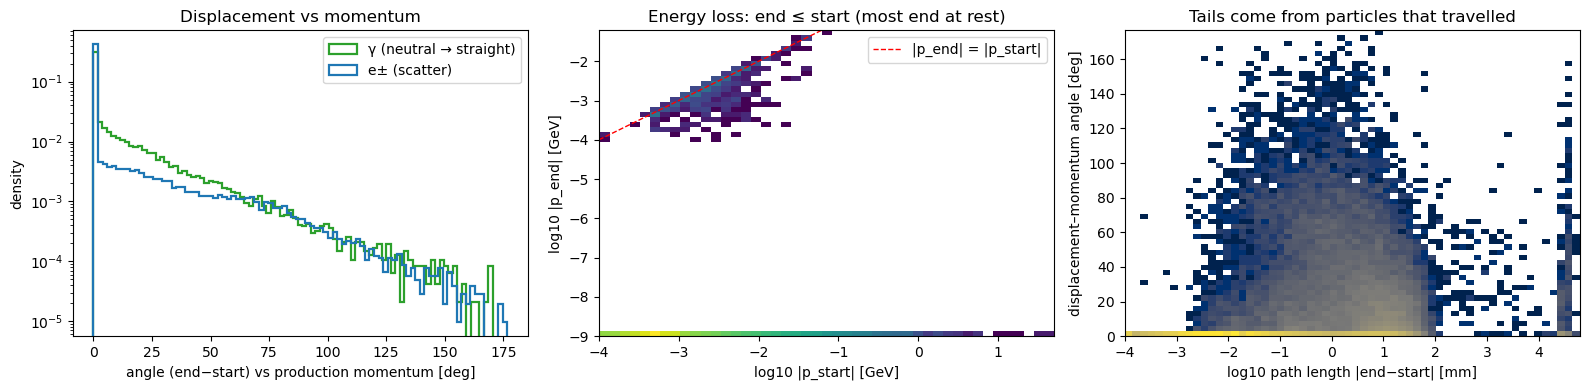

fraction with |p_end| <= |p_start|: 100.0%;  fraction ending at rest (p_end<1e-4 GeV): 99.3%
photons ending at p≈0 (converted/absorbed): 24,356 / 24,914


In [17]:
# 1) masses vs PDG
mm = lambda s: float(mass[s].mean()) if s.any() else float("nan")
print("MASS CHECK [GeV]:")
print(f"  e-: {mm(pdg==11):.6f}   e+: {mm(pdg==-11):.6f}   gamma: {mm(pdg==22):.6f}   (PDG: 0.000511, 0.000511, 0)")

# 2) first-vertex energy conservation. Pair-production products share the photon's conversion
#    point *exactly* (same Geant4 step point), so a 1 µm tolerance isolates them from the
#    downstream secondaries (born further along, once the e± have travelled a finite distance).
def _within(tol):
    return (np.abs(vsx-vex[0]) < tol) & (np.abs(vsy-vey[0]) < tol) & (np.abs(vsz-vez[0]) < tol)
conv = np.where(_within(1e-3))[0]
conv = conv[conv != 0]   # exclude the primary itself (it ends far from where it started)
print(f"\nPRIMARY: pdg={pdg[0]}, E={E[0]:.2f} GeV, converts at ({vex[0]:.1f},{vey[0]:.1f},{vez[0]:.1f}) mm")
print(f"products born there: {len(conv)} particle(s), pdg={sorted(set(int(pdg[i]) for i in conv))}, "
      f"E = {' + '.join(f'{E[i]:.2f}' for i in conv)} = {E[conv].sum():.2f} GeV  (= primary {E[0]:.2f} GeV)")
print(f"  isolation check - particles within 1 µm / 10 µm / 100 µm of the conversion point: "
      f"{int(_within(1e-3).sum())} / {int(_within(1e-2).sum())} / {int(_within(1e-1).sum())}")

# 3) displacement vs momentum, and 4) energy loss
disp = np.stack([vex-vsx, vey-vsy, vez-vsz], axis=1); dlen = np.linalg.norm(disp, axis=1)
pvec = np.stack([px, py, pz], axis=1);                pm   = np.linalg.norm(pvec, axis=1)
ok = (dlen > 1e-6) & (pm > 1e-9)
ang = np.degrees(np.arccos(np.clip(np.einsum("ij,ij->i", disp[ok], pvec[ok]) / (dlen[ok]*pm[ok]), -1, 1)))
okp = pdg[ok]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
# (a) displacement vs PRODUCTION momentum, by species
for sel, lab, col in [(okp==22,"γ (neutral → straight)","#2ca02c"), ((okp==11)|(okp==-11),"e± (scatter)","#1f77b4")]:
    if sel.any():
        ax[0].hist(ang[sel], bins=90, histtype="step", lw=1.6, color=col, label=lab, density=True)
ax[0].set_yscale("log"); ax[0].set_xlabel("angle (end−start) vs production momentum [deg]")
ax[0].set_ylabel("density"); ax[0].set_title("Displacement vs momentum"); ax[0].legend()

# (b) energy loss: end vs start momentum -- nearly everything ends at rest
pend = np.sqrt(pex**2 + pey**2 + pez**2); s = pm > 0
ax[1].hist2d(np.log10(np.clip(pm[s],1e-6,None)), np.log10(np.clip(pend[s],1e-9,None)),
             bins=[60,60], cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
lim = [-4, np.log10(pm.max())]
ax[1].plot(lim, lim, "r--", lw=1, label="|p_end| = |p_start|")
ax[1].set_xlim(lim); ax[1].set_ylim(bottom=-9)
ax[1].set_xlabel("log10 |p_start| [GeV]"); ax[1].set_ylabel("log10 |p_end| [GeV]")
ax[1].set_title("Energy loss: end ≤ start (most end at rest)"); ax[1].legend()
ax[1].annotate("bottom row = stopped (p_end ≈ 0)", xy=(0.5, 0.03), xycoords="axes fraction",
               ha="center", fontsize=7, color="white")

# (c) WHY the tails -- the deflected particles are the ones that TRAVELLED far
ax[2].hist2d(np.log10(np.clip(dlen[ok], 1e-4, None)), ang, bins=[60, 60],
             cmap="cividis", norm=plt.matplotlib.colors.LogNorm())
ax[2].set_xlabel("log10 path length |end−start| [mm]"); ax[2].set_ylabel("displacement–momentum angle [deg]")
ax[2].set_title("Tails come from particles that travelled")
plt.tight_layout(); plt.show()
print(f"fraction with |p_end| <= |p_start|: {(pend <= pm + 1e-6).mean():.1%};  "
      f"fraction ending at rest (p_end<1e-4 GeV): {(pend < 1e-4).mean():.1%}")
print(f"photons ending at p≈0 (converted/absorbed): {int(((pdg==22)&(pend<1e-4)).sum()):,} / {int((pdg==22).sum()):,}")

**Reading the panels.** *Left:* photons (green) pile up at angle ≈ 0 — straight until a
discrete interaction — while the electron distribution has a long tail to large angles.
*Middle:* the dense **bottom row** is the ~99% of tracks that end at rest (p_end ≈ 0); the
cascade fully thermalises, so essentially everything loses ~100% of its momentum and "momentum
change" *cannot by itself* explain the angular tails. The red diagonal is the |p_end| = |p_start|
ceiling, which nothing crosses. *Right:* here the dense **bottom row** is the majority that go
essentially straight (displacement angle ≈ 0) — they stop before travelling far, or are neutral
photons. The angle only grows with **path length**: large-angle electrons travelled ~90× farther
than the straight ones (more distance ⇒ more accumulated multiple scattering), and large-angle
photons ~3× farther (they Compton-scattered, then continued). So the tails *are* the "affected"
particles — picked out by distance travelled, not by momentum lost.

### The cascade tree — who made whom

Using the parent→daughter links (extracted from the EDM4hep `daughters` relation) we can draw
the actual **cascade tree**, not a set of disconnected tracks. Starting from the primary photon
we follow its hardest descendants, so every drawn track's parent is also drawn: the segments
**branch at the vertices** where new particles are created, and the electron → photon →
electron alternation of an electromagnetic shower becomes visible. Each segment runs from a
particle's production vertex to its end point, coloured by species. We keep the hardest ~120
*connected* e±/γ — the visible skeleton, with the soft sea omitted — and clip the incoming
photon to the ECal front (y = 1264 mm). **Left:** the shower *in space* (depth vs transverse),
each track shaded and weighted by energy, with the production vertices marked. **Right:** an
abstract **genealogy** — generation from the primary on the x-axis, one node per particle,
edges from parent to child — which makes the branching and the brem photons easy to follow even
where they overlap in space.

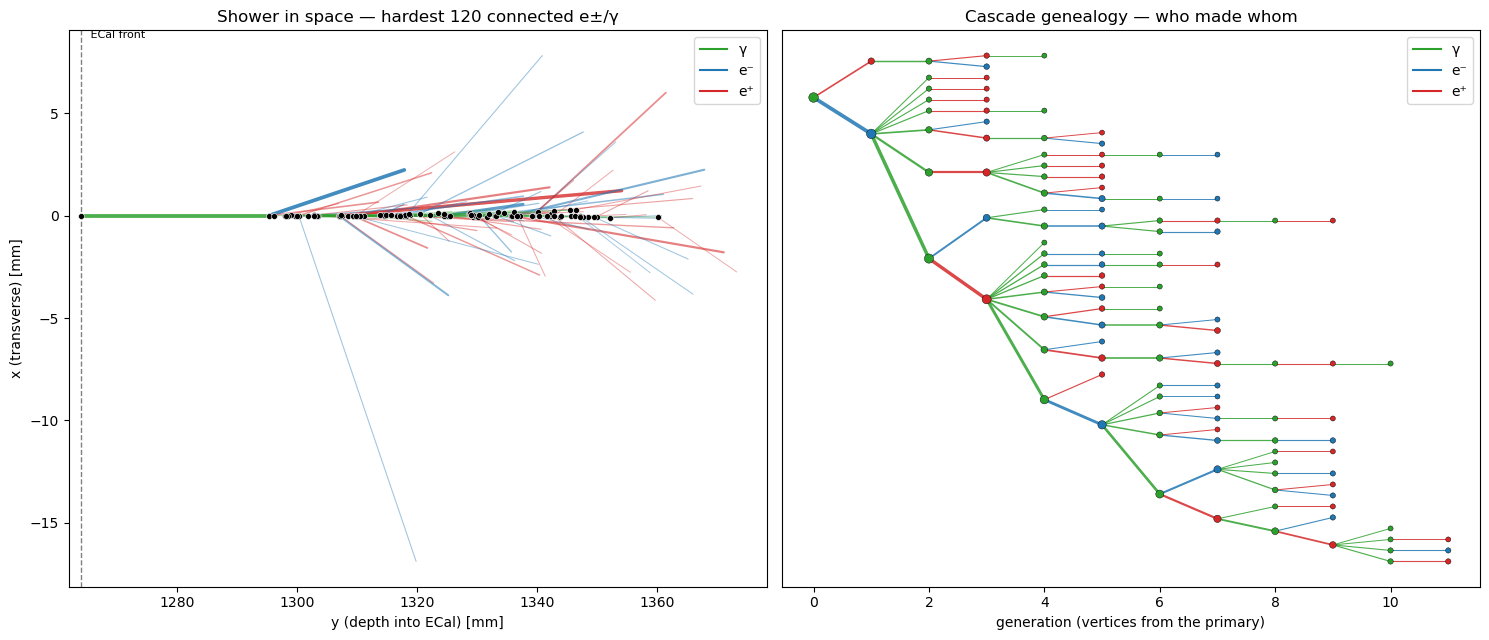

tree: 120 connected nodes — 64 e± + 56 γ; root = primary photon (50 GeV); max generation = 11
branching example — the primary's daughters: [(11, 47.59), (-11, 2.41)] GeV
edge processes (parent → child): γ→e⁺=35, γ→e⁻=29, e⁺→γ=29, e⁻→γ=26


In [18]:
import heapq
# dbeg/dend/dau already bound in the array-pull cell above
children = lambda i: [int(c) for c in dau[dbeg[i]:dend[i]]]

# Grow a CONNECTED tree from the primary (index 0): expand into the highest-energy reachable
# e±/γ daughter until N nodes, recording each node's parent so we can draw the genealogy.
N = 120
keep, seen, parent, heap = [], set(), {0: None}, [(-float(E[0]), 0)]
while heap and len(keep) < N:
    negE, i = heapq.heappop(heap)
    if i in seen:
        continue
    seen.add(i); keep.append(i)
    for c in children(i):
        if c not in seen and int(pdg[c]) in (22, 11, -11):
            parent.setdefault(c, i)
            heapq.heappush(heap, (-float(E[c]), c))
keepset = set(keep)

cmap = {22: "#2ca02c", 11: "#1f77b4", -11: "#d62728"}; pcol = lambda p: cmap[int(p)]
lw   = lambda e: 0.5 + 1.3*np.log10(max(e, 1e-3) + 1)
alph = lambda e: float(np.clip(0.35 + 0.5*np.log10(max(e, 1e-3) + 1)/np.log10(51), 0.35, 0.95))
zo   = lambda p: 3 if int(p) == 22 else 2          # draw photons over e+- so they stay visible
cy   = lambda v: max(float(v), 1264.0)             # clip the incoming primary photon to the ECal front
from matplotlib.lines import Line2D
legend = [Line2D([0],[0],color=c,label=l) for l,c in [("γ","#2ca02c"),("e⁻","#1f77b4"),("e⁺","#d62728")]]

fig = plt.figure(figsize=(15, 6.5))
# --- left: the shower in space (depth vs transverse) ---
ax2 = fig.add_subplot(1, 2, 1)
for i in keep:
    ax2.plot([cy(vsy[i]), vey[i]], [vsx[i], vex[i]], color=pcol(pdg[i]), lw=lw(E[i]),
             alpha=alph(E[i]), solid_capstyle="round", zorder=zo(pdg[i]))
ax2.scatter([cy(vsy[i]) for i in keep], [vsx[i] for i in keep], s=18, color="k",
            edgecolor="w", linewidth=0.4, zorder=5)
ax2.axvline(1264, ls="--", color="grey", lw=1); ax2.text(1265, ax2.get_ylim()[1], " ECal front", fontsize=8, va="top")
ax2.set_xlim(1262, max(vey[i] for i in keep) + 5)
ax2.set_xlabel("y (depth into ECal) [mm]"); ax2.set_ylabel("x (transverse) [mm]")
ax2.set_title(f"Shower in space — hardest {len(keep)} connected e±/γ"); ax2.legend(handles=legend, loc="upper right")

# --- right: genealogy tree-graph (generation x layout); photons become distinct nodes ---
ax3 = fig.add_subplot(1, 2, 2)
kids = {i: [] for i in keep}
for c in keep:
    if parent.get(c) in keepset: kids[parent[c]].append(c)
gen = {}
def _gen(i):
    if i not in gen:
        p = parent.get(i); gen[i] = 0 if (p is None or p not in keepset) else _gen(p) + 1
    return gen[i]
for i in keep: _gen(i)
ypos, ctr = {}, [0]
def _layout(i):
    ks = sorted(kids[i], key=lambda c: -E[c])
    if not ks:
        ypos[i] = ctr[0]; ctr[0] += 1
    else:
        for c in ks: _layout(c)
        ypos[i] = float(np.mean([ypos[c] for c in ks]))
for r in [i for i in keep if parent.get(i) not in keepset]: _layout(r)
for c in keep:
    if parent.get(c) in keepset:
        ax3.plot([gen[parent[c]], gen[c]], [ypos[parent[c]], ypos[c]],
                 color=pcol(pdg[c]), lw=lw(E[c]), alpha=0.85, zorder=zo(pdg[c]))
ax3.scatter([gen[i] for i in keep], [ypos[i] for i in keep], c=[pcol(pdg[i]) for i in keep],
            s=[10 + 22*np.log10(max(E[i], 1e-3) + 1) for i in keep], edgecolor="k", linewidth=0.3, zorder=5)
ax3.set_xlabel("generation (vertices from the primary)"); ax3.set_yticks([])
ax3.set_title("Cascade genealogy — who made whom"); ax3.legend(handles=legend, loc="upper right")
plt.tight_layout(); plt.show()

n_g = sum(1 for i in keep if pdg[i] == 22); n_em = len(keep) - n_g
print(f"tree: {len(keep)} connected nodes — {n_em} e± + {n_g} γ; root = primary photon ({E[0]:.0f} GeV); "
      f"max generation = {max(gen.values())}")
print(f"branching example — the primary's daughters: {[(int(pdg[c]), round(float(E[c]),2)) for c in children(0)]} GeV")
import collections as _coll
_t = _coll.Counter((int(pdg[parent[c]]), int(pdg[c])) for c in keep if parent.get(c) in keepset)
_nm = {22: "γ", 11: "e⁻", -11: "e⁺"}
print("edge processes (parent → child): " + ", ".join(f"{_nm[a]}→{_nm[b]}={n}" for (a, b), n in sorted(_t.items(), key=lambda x: -x[1])))

**Reading the genealogy — an edge means *produced*, not *became*.** A particle keeps going
after it spawns a child; only pair production and annihilation actually *consume* the parent.
Two processes drive the cascade, and the printed edge counts show both directions in roughly
equal measure:
- **γ → e⁺e⁻** (pair production): a photon converts into an electron–positron pair and is gone.
- **e± → γ** (bremsstrahlung) — plus **e⁺ → γγ** annihilation at the end of a positron's range:
  a charged particle radiates photons *at many successive points along its track* while
  continuing on. That is why one hard e± fathers a whole fan of photons (the 47.6 GeV electron
  here emits dozens of bremsstrahlung photons before it stops; a stopping positron ends by
  annihilating into two 0.511 MeV photons).

So "a positron turning into photons" is really *radiate-along-the-track, then annihilate*, and
"an electron into many photons" is *bremsstrahlung at many vertices*. Those emission points are
real, **distinct vertices spread along each track** — visible as the black dots strung along the
tracks in the left (spatial) panel. The genealogy collapses them onto one node per particle to
show the lineage cleanly; the spatial panel is where their positions live.

## Summary

- The per-sensor crossing product is produced programmatically from the simulation: the ECal
  silicon is read out as a Geant4 **tracker**, so each `SimTrackerHit` is one crossing
  carrying the **real** impact point, direction and **momentum** —
  `analysis/sensor_crossings.py` (variant C) reshapes them into per-crossing records with
  `cot α`/`cot β`, `|p|` and particle type.
- `sensor_crossings.py` auto-selects the readout **variant**: **C** (this notebook) uses the
  tracker hit's real momentum; **A** (the calorimeter route, notebook 07) time-orders the step
  deposits and uses the production momentum; **B** is the coarsest pixel-centroid fallback.
  C is preferred wherever a tracker readout is available.
- The reconstruction choices are validated against the data: the +y face at 90°, layers
  labelled by depth, the real momentum (on/below the production diagonal, softening with
  depth), the expected hard-perpendicular / soft-wide angular behaviour — and, externally,
  the byte-identical cascade across readouts and the 85 keV silicon-MIP Landau (§8).
- **The deliverable** is the per-crossing table written in §7 (`.json`/`.csv`): position,
  direction, momentum and particle type for every charged-track crossing of every silicon
  sensor. [**07**](07_sensor_crossings_calo.ipynb) builds the same crossings from calorimeter
  step truth as a cross-check; the `pixelav-inputs` branch converts these tables into
  ready-to-run input decks for PIXELAV, our collaborators' silicon charge-transport
  simulation.
